In [1]:
%% Name: Oluwatobi Olatunji
%% Date: 11/03/2026
%% Purpose:  Implement deep neural network architecture in MATLAB, train train and test using the Digit dataset.


## Initialize The Environment

In [2]:
close all;
clear;
clc;


## Load The Covid Dataset

In [3]:
imds = imageDatastore('COVIDDATASET', ...
    'IncludeSubfolders', true, ...
    'LabelSource', 'foldernames')

imds = 
  ImageDatastore with properties:
                       Files: {
                              '/MATLAB Drive/COVIDDATASET/Covid/COVID-1.png';
                              '/MATLAB Drive/COVIDDATASET/Covid/COVID-10.png';
                              '/MATLAB Drive/COVIDDATASET/Covid/COVID-100.png'
                               ... and 20312 more
                              }
                     Folders: {
                              '/MATLAB Drive/COVIDDATASET'
                              }
                      Labels: [Covid; Covid; Covid ... and 20312 more categorical]
    AlternateFileSystemRoots: {}
                    ReadSize: 1
      SupportedOutputFormats: ["png"    "jpg"    "jpeg"    "tif"    "tiff"]
         DefaultOutputFormat: "png"
                     ReadFcn: @readDatastoreImage


## Explore the dataset

In [4]:
% Count images per class and display as table
tbl = countEachLabel(imds);
disp('Number of images per class:')

Number of images per class:

In [5]:
labelCount = countEachLabel(imds)

In [6]:
% Total classes and images
numTotalClasses = numel(categories(imds.Labels));
numTotalImages  = numel(imds.Files);
fprintf('Total classes: %d\n', numTotalClasses)

Total classes: 4

In [7]:
fprintf('Total images: %d\n', numTotalImages)

Total images: 20315

In [8]:
% Check size of first image
img = readimage(imds, 1);
fprintf('Original image size: %dx%dx%d\n', size(img,1), size(img,2), size(img,3))

Original image size: 299x299x1


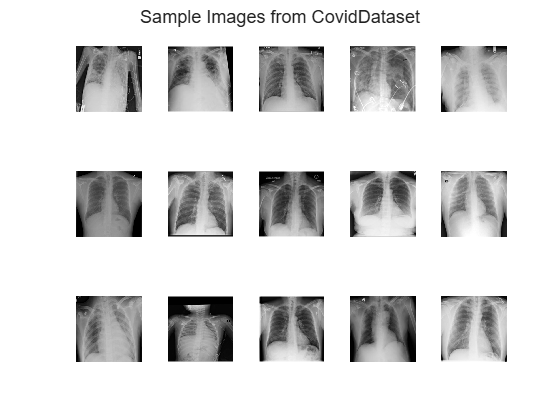

In [9]:
% Display 15 random images from the dataset
figure;
perm = randperm(numTotalImages, 15);
for i = 1:15
    subplot(3,5,i);
    imshow(readimage(imds, perm(i)));
end
sgtitle('Sample Images from CovidDataset')


## Visualise class distribution


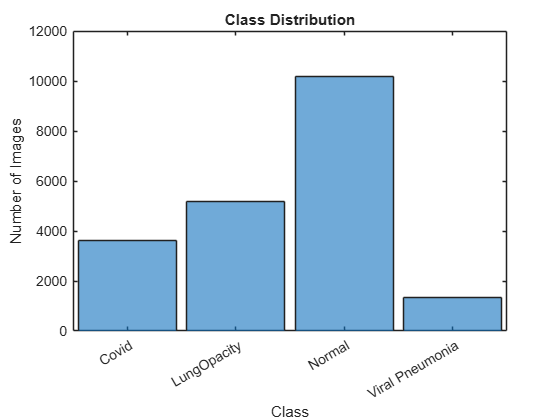

In [10]:
% Visualise class distribution
figure;
histogram(imds.Labels)
title('Class Distribution')
set(gca, 'TickLabelInterpreter', 'none')
ylabel('Number of Images')
xlabel('Class')


## Balance the Dataset (undersample)

In [11]:
%% Balance Dataset (undersampling to smallest class)


labelCount = countEachLabel(imds);
minCount = min(labelCount.Count);


imdsBalanced = splitEachLabel(imds, minCount, 'randomized');


countEachLabel(imdsBalanced)


## SPLIT DATA  \-  70% Train | 15% Validation | 15% Test

In [12]:
trainRatio = 0.70;
valRatio   = 0.15;
testRatio  = 0.15;

[imdsTrain, imdsValidation, imdsTest] = splitEachLabel(imdsBalanced, ...
    trainRatio, valRatio, testRatio, 'randomized');

fprintf('Training images:   %d\n', numel(imdsTrain.Files))

Training images:   3764

In [13]:
fprintf('Validation images: %d\n', numel(imdsValidation.Files))

Validation images: 808

In [14]:
fprintf('Test images:       %d\n', numel(imdsTest.Files))

Test images:       808


## Resize for CNN (best method)


In [15]:
%% =========================
%  1. INPUT IMAGE SIZE
%% =========================
inputSize = [128 128 1];


%% =========================
%  2. IMAGE AUGMENTATION (TRAINING ONLY)
%% =========================
augmenter = imageDataAugmenter( ...
    'RandXReflection', true, ...
    'RandRotation', [-15 15], ...
    'RandXTranslation', [-5 5], ...
    'RandYTranslation', [-5 5]);


%% =========================
%  3. TRAINING DATA (WITH AUGMENTATION)
%% =========================
imdsTrain_resized = augmentedImageDatastore( ...
    inputSize, imdsTrain, ...
    'ColorPreprocessing', 'rgb2gray', ...
    'DataAugmentation', augmenter);


%% =========================
%  4. VALIDATION DATA (NO AUGMENTATION)
%% =========================
imdsValidation_resized = augmentedImageDatastore( ...
    inputSize, imdsValidation, ...
    'ColorPreprocessing', 'rgb2gray');


%% =========================
%  5. TEST DATA (NO AUGMENTATION)
%% =========================
imdsTest_resized = augmentedImageDatastore( ...
    inputSize, imdsTest, ...
    'ColorPreprocessing', 'rgb2gray');

In [16]:


preview(imdsTrain_resized)


## Create CNN Architecture

In [17]:
layers = [


imageInputLayer([128 128 1])


convolution2dLayer(3,8,'Padding','same')
batchNormalizationLayer
reluLayer
maxPooling2dLayer(2,'Stride',2)


convolution2dLayer(3,16,'Padding','same')
batchNormalizationLayer
reluLayer
maxPooling2dLayer(2,'Stride',2)


convolution2dLayer(3,32,'Padding','same')
batchNormalizationLayer
reluLayer
maxPooling2dLayer(2,'Stride',2)


fullyConnectedLayer(64)
reluLayer
%dropoutLayer(0.2)   % ← NEW (50% neurons randomly off)


fullyConnectedLayer(4)
softmaxLayer
classificationLayer];






## Analyse the network structure

In [18]:
analyzeNetwork(layers)

In [19]:
optimizers = ["sgdm","adam","rmsprop"];
results = {};

Training with sgdm optimizer...


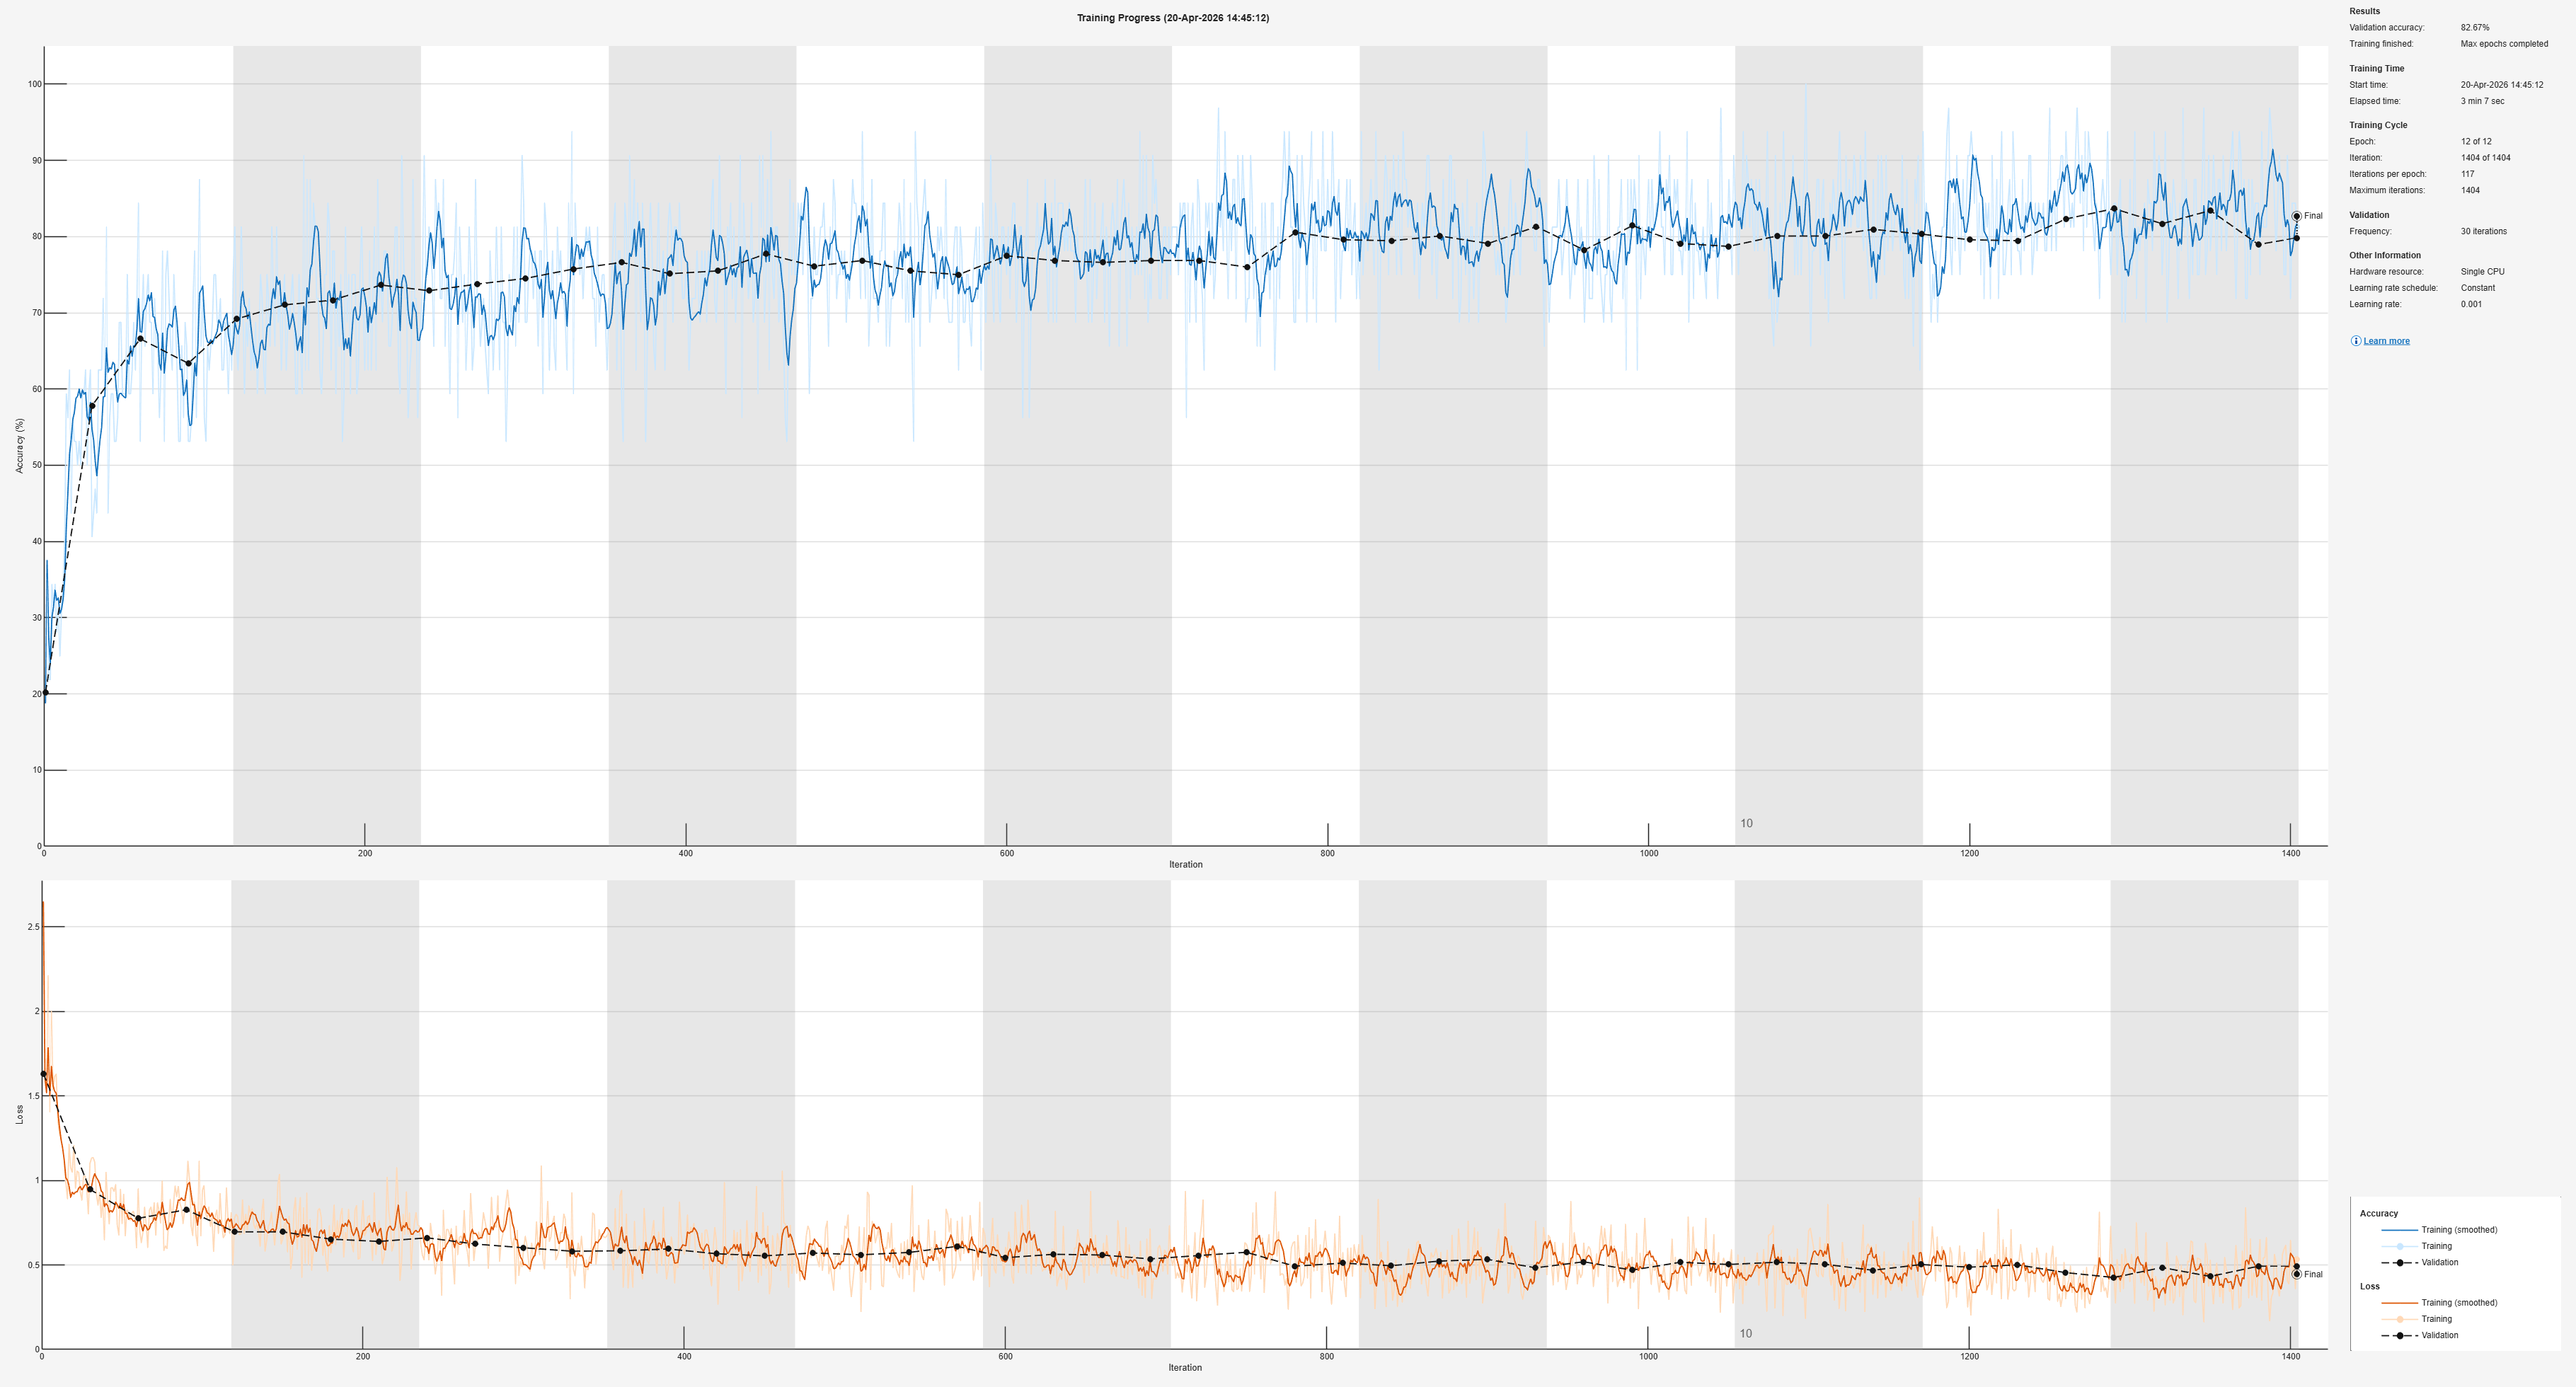

Training with adam optimizer...


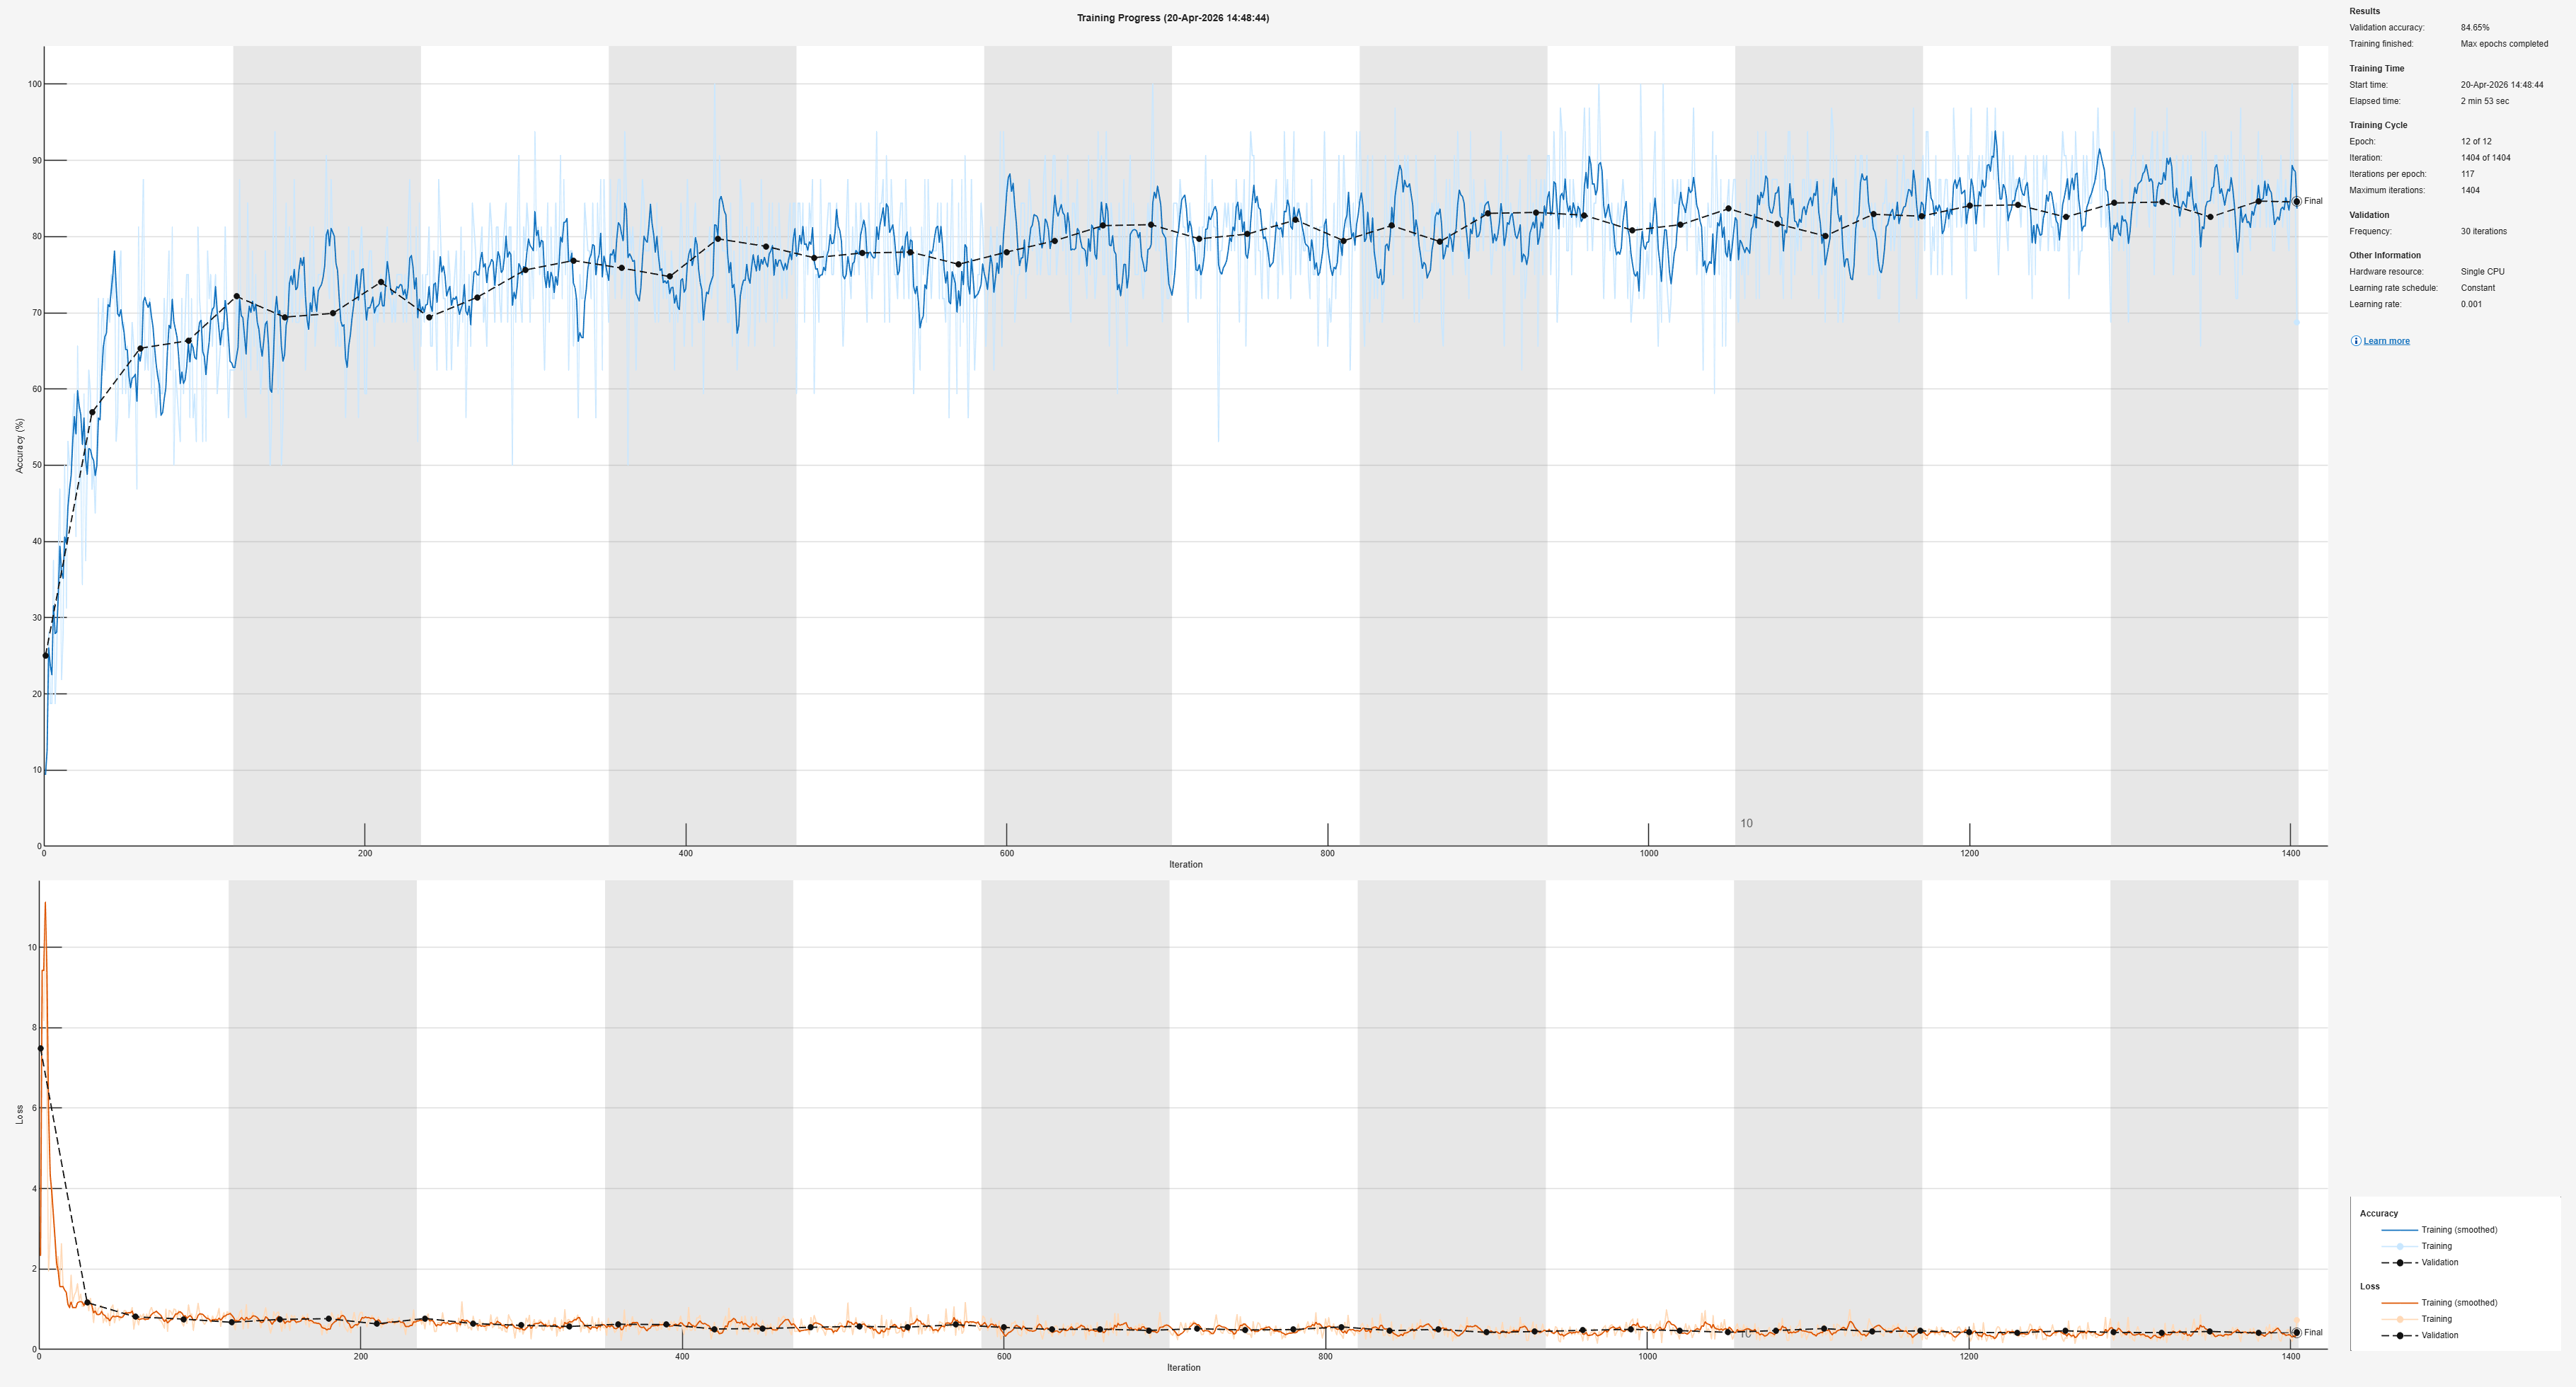

Training with rmsprop optimizer...


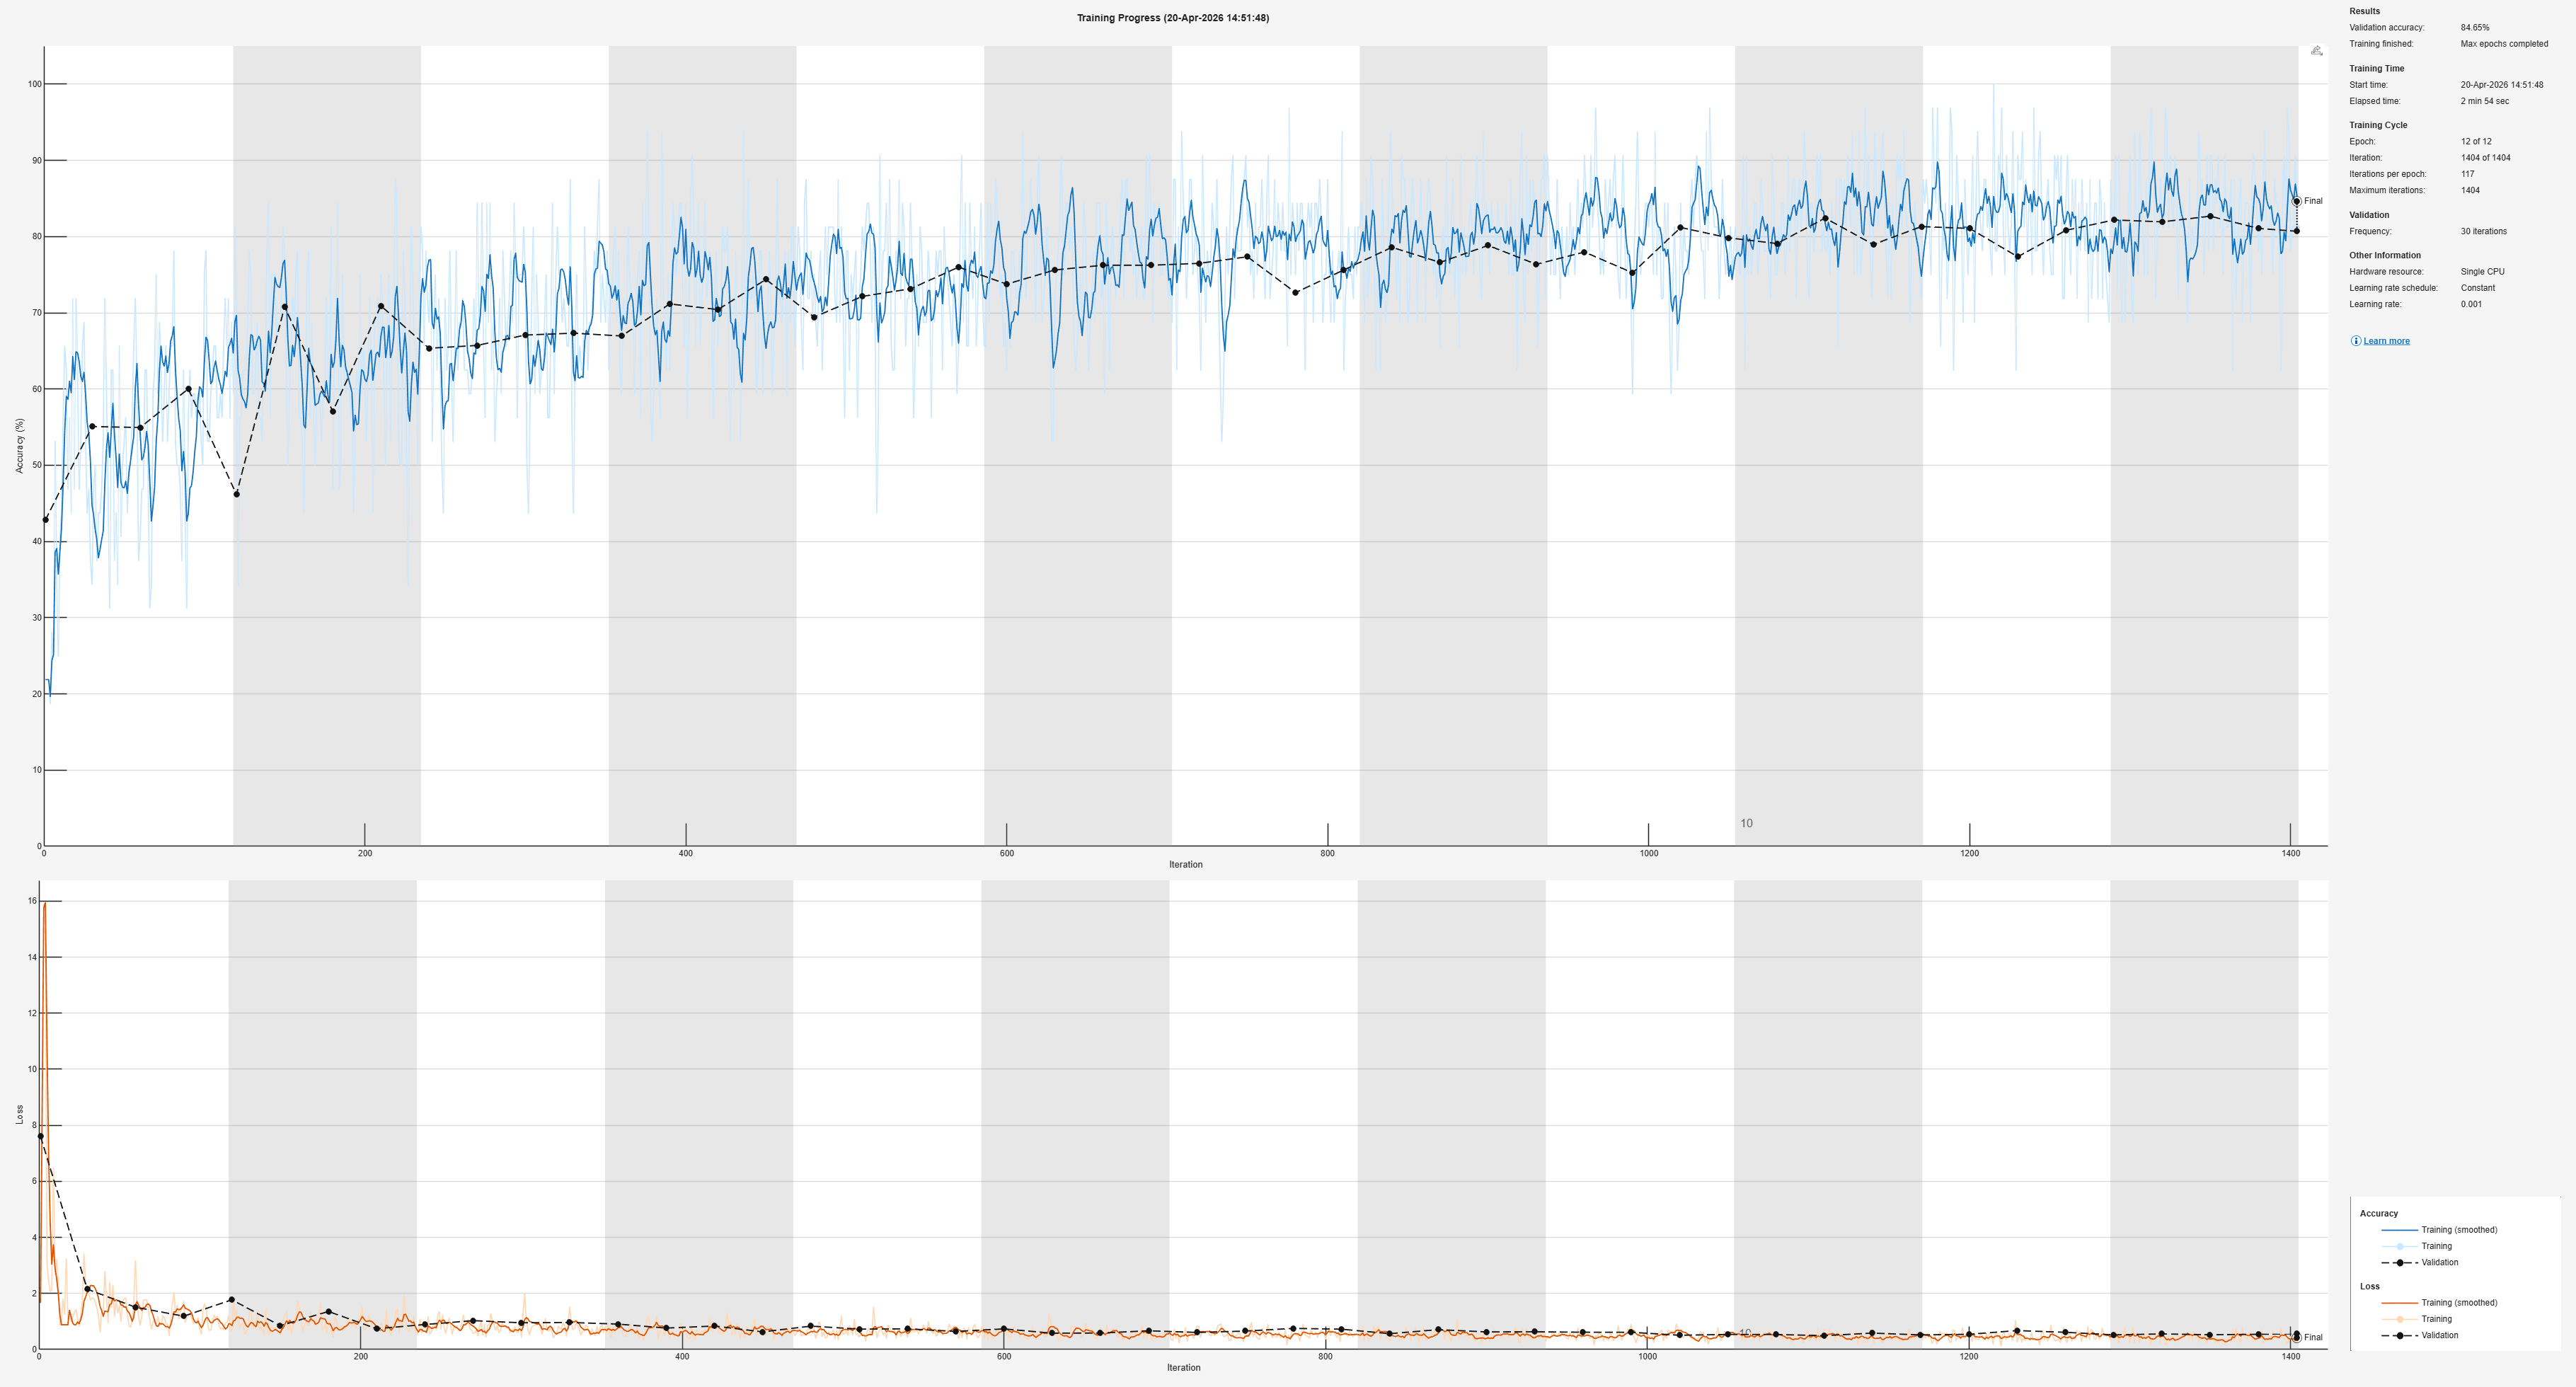

In [20]:
for i = 1:length(optimizers)


    opt = optimizers(i);


    options = trainingOptions(opt, ...
        'InitialLearnRate', 0.001, ...
        'MaxEpochs', 12, ...
        'MiniBatchSize', 32, ...
        'Shuffle', 'every-epoch', ...
        'ValidationData', imdsValidation_resized, ...
        'ValidationFrequency', 30, ...
        'Verbose', false, ...
        'Plots','training-progress');


    fprintf('Training with %s optimizer...\n', opt);


    %net = trainNetwork(imdsTrain_resized, layers, options);
    [net, info] = trainNetwork(imdsTrain_resized, layers, options);


    nets{i} = net;
    infos{i} = info;   % store training info for plotting


    % Validation Accuracy
    YPredVal = classify(net, imdsValidation_resized);
    YVal = imdsValidation.Labels;
    valAcc = sum(YPredVal == YVal)/numel(YVal) * 100;


    % Test Accuracy
    YPredTest = classify(net, imdsTest_resized);
    YTest = imdsTest.Labels;
    testAcc = sum(YPredTest == YTest) / numel(YTest) * 100;


    % Save results
    results = [results; {char(opt), valAcc, testAcc}];


end


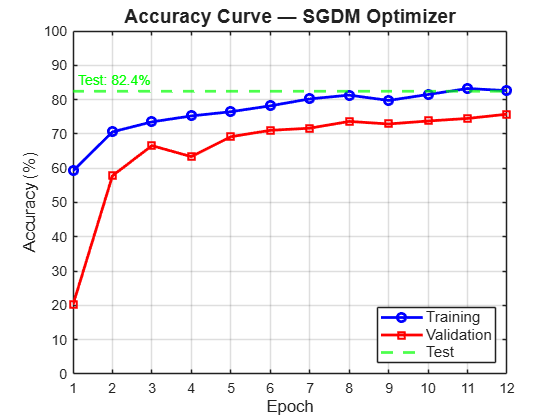


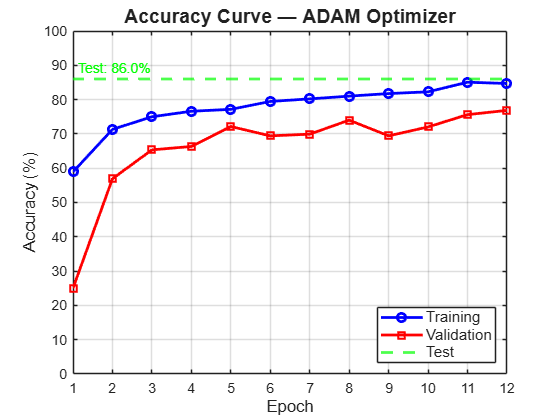

In [21]:
% =========================================================
% PLOT ACCURACY CURVES - ONE FIGURE PER OPTIMIZER
% =========================================================


optimizerNames = {'SGDM', 'ADAM', 'RMSProp'};


for i = 1:length(optimizers)
    info = infos{i};


    % --- Extract validation accuracy (remove NaN placeholders) ---
    valAcc_curve = info.ValidationAccuracy;
    valAcc_curve(isnan(valAcc_curve)) = [];


    % --- Extract training accuracy per epoch ---
    % Average iterations within each epoch to get one value per epoch
    numEpochs    = 12;
    iterPerEpoch = floor(size(imdsTrain_resized.Files, 1) / 32);
    trainAcc_curve = zeros(1, numEpochs);
    for e = 1:numEpochs
        startIdx = (e-1)*iterPerEpoch + 1;
        endIdx   = min(e*iterPerEpoch, numel(info.TrainingAccuracy));
        trainAcc_curve(e) = mean(info.TrainingAccuracy(startIdx:endIdx), 'omitnan');
    end


    % --- Test accuracy (single value -> flat dashed line) ---
    testAccVal = results{i, 3};


    % --- Plot ---
    epochs = 1:numEpochs;
    figure('Name', ['Accuracy Curve - ' optimizerNames{i}], 'NumberTitle', 'off')
    plot(epochs, trainAcc_curve, 'b-o', 'LineWidth', 2, 'MarkerSize', 6)
    hold on
    plot(epochs, valAcc_curve(1:numEpochs), 'r-s', 'LineWidth', 2, 'MarkerSize', 6)
    yline(testAccVal, 'g--', sprintf('Test: %.1f%%', testAccVal), ...
        'LineWidth', 2, 'LabelHorizontalAlignment', 'left')
    hold off
    xlabel('Epoch', 'FontSize', 12)
    ylabel('Accuracy (%)', 'FontSize', 12)
    title(['Accuracy Curve — ' optimizerNames{i} ' Optimizer'], 'FontSize', 14)
    legend({'Training', 'Validation', 'Test'}, 'Location', 'southeast', 'FontSize', 11)
    xlim([1 numEpochs])
    ylim([0 100])
    xticks(epochs)
    grid on
end


<center>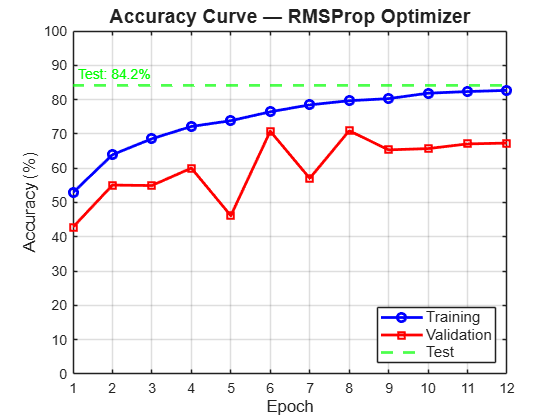</center>

## Classify Validation Images and Compute validation Accuracy

In [22]:
resultsTable = cell2table(results, ...
    'VariableNames', {'Optimizer','ValidationAccuracy','TestAccuracy'});
disp(resultsTable)

     Optimizer     ValidationAccuracy    TestAccuracy
    ___________    __________________    ____________
    {'sgdm'   }          82.673             82.426   
    {'adam'   }          84.653             86.015   
    {'rmsprop'}          84.653             84.158

In [23]:


 % options = trainingOptions('sgdm', ...
  % 'InitialLearnRate', 0.001, ...
  %  'MaxEpochs', 12, ...
  %  'MiniBatchSize', 32, ...
  %  'Shuffle', 'every-epoch', ...
  % 'ValidationData', imdsValidation_resized, ...
  %  'ValidationFrequency', 30, ...
  %  'Verbose', false, ...
   % 'Plots', 'training-progress');


  %options = trainingOptions('adam', ...
   % 'InitialLearnRate', 0.001, ...
  %  'MaxEpochs', 12, ...
   % 'MiniBatchSize', 32, ...
   % 'Shuffle', 'every-epoch', ...
   % 'ValidationData', imdsValidation_resized, ...
   % 'ValidationFrequency', 30, ...
   % 'Verbose', false, ...
   % 'Plots', 'training-progress');


% options = trainingOptions('rmsprop', ...
  %  'InitialLearnRate', 0.001, ...
  %  'MaxEpochs', 12, ...
  %  'MiniBatchSize', 32, ...
  %  'Shuffle', 'every-epoch', ...
  %  'ValidationData', imdsValidation_resized, ...
  %  'ValidationFrequency', 30, ...
   % 'Verbose', false, ...
   % 'Plots', 'training-progress');











## Confusion Matrix


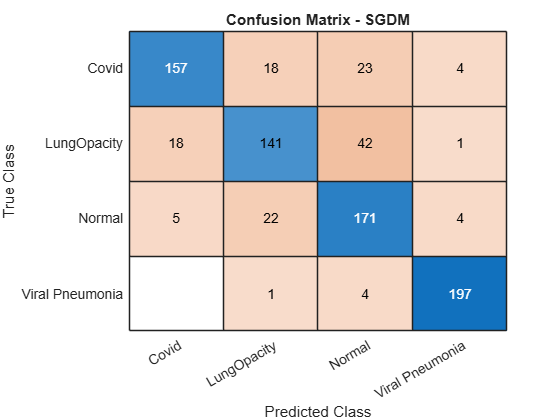


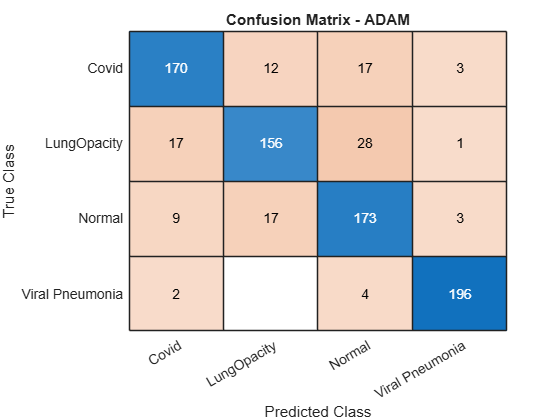

In [24]:
optimizerNames = ["SGDM","ADAM","RMSprop"];


for i = 1:length(nets)


    net = nets{i};


    YPred = classify(net, imdsTest_resized);
    YTest = imdsTest.Labels;


    figure;
    confusionchart(YTest, YPred);
    title(['Confusion Matrix - ' char(optimizerNames(i))]);


end


<center>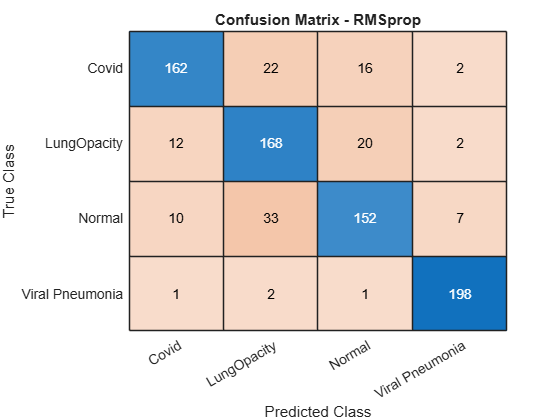</center>


In [25]:
 optimizerNames = ["SGDM","ADAM","RMSprop"];


for i = 1:length(nets)


    net = nets{i};


    YPred = classify(net, imdsTest_resized);
    YTest = imdsTest.Labels;


    confMat = confusionmat(YTest, YPred);


    numClasses = size(confMat,1);
    precision = zeros(numClasses,1);
    recall = zeros(numClasses,1);
    f1score = zeros(numClasses,1);


    for j = 1:numClasses
        TP = confMat(j,j);
        FP = sum(confMat(:,j)) - TP;
        FN = sum(confMat(j,:)) - TP;


        precision(j) = TP / (TP + FP + eps);
        recall(j)    = TP / (TP + FN + eps);
        f1score(j)   = 2 * (precision(j)*recall(j)) / ...
                       (precision(j)+recall(j) + eps);
    end


    resultsTable = table(categories(YTest), precision, recall, f1score, ...
        'VariableNames', {'Class','Precision','Recall','F1Score'});


    fprintf('\nMetrics for %s Optimizer\n', optimizerNames(i));
    disp(resultsTable);


end

Metrics for SGDM Optimizer
           Class           Precision    Recall     F1Score
    ___________________    _________    _______    _______
    {'Covid'          }     0.87222     0.77723    0.82199
    {'LungOpacity'    }     0.77473     0.69802    0.73437
    {'Normal'         }      0.7125     0.84653    0.77376
    {'Viral Pneumonia'}     0.95631     0.97525    0.96569
Metrics for ADAM Optimizer
           Class           Precision    Recall     F1Score
    ___________________    _________    _______    _______
    {'Covid'          }     0.85859     0.84158       0.85
    {'LungOpacity'    }     0.84324     0.77228     0.8062
    {'Normal'         }     0.77928     0.85644    0.81604
    {'Viral Pneumonia'}     0.96552      0.9703     0.9679
Metrics for RMSprop Optimizer
           Class           Precision    Recall     F1Score
    ___________________    _________    _______    _______
    {'Covid'          }     0.87568     0.80198    0.83721
    {'LungOpacity'    }     0.7

In [26]:
optimizerNames = ["SGDM","ADAM","RMSprop"];


for i = 1:length(nets)


    net = nets{i};


    YPred = classify(net, imdsTest_resized);
    YTest = imdsTest.Labels;


    confMat = confusionmat(YTest, YPred);


    % ---- Overall Metrics ----
    TP = sum(diag(confMat));                 % All correct predictions
    FP = sum(confMat(:)) - TP;              % All wrong positives
    FN = FP;


    overallPrecision = TP / (TP + FP + eps);
    overallRecall    = TP / (TP + FN + eps);
    overallF1        = 2 * (overallPrecision * overallRecall) / ...
                       (overallPrecision + overallRecall + eps);


    fprintf('\nOverall Metrics for %s Optimizer\n', optimizerNames(i));
    fprintf('Overall Precision: %.4f\n', overallPrecision);
    fprintf('Overall Recall: %.4f\n', overallRecall);
    fprintf('Overall F1-Score: %.4f\n', overallF1);


end

Overall Metrics for SGDM Optimizer
Overall Precision: 0.8243
Overall Recall: 0.8243
Overall F1-Score: 0.8243
Overall Metrics for ADAM Optimizer
Overall Precision: 0.8601
Overall Recall: 0.8601
Overall F1-Score: 0.8601
Overall Metrics for RMSprop Optimizer
Overall Precision: 0.8416
Overall Recall: 0.8416
Overall F1-Score: 0.8416

In [27]:
%% Precision, Recall, F1 per Class
numClasses = size(confMat,1) %Return the number of rows in the confusion matrix

numClasses = 4


## MODEL ResNet\-50 (2015)

In [28]:
net = resnet50;
lgraph = layerGraph(net);


## Replace Final Layers (4 classes)

In [29]:
numClasses = 4;


newLayers = [
    fullyConnectedLayer(numClasses,'Name','fc_new')
    softmaxLayer('Name','softmax_new')
    classificationLayer('Name','classoutput_new')];


lgraph = replaceLayer(lgraph,'fc1000',newLayers(1));
lgraph = replaceLayer(lgraph,'fc1000_softmax',newLayers(2));
lgraph = replaceLayer(lgraph,'ClassificationLayer_fc1000',newLayers(3));


## Train with SGDM only (Transfer Learning settings)

In [30]:
inputSize = [224 224 3];


imdsTrain_resized = augmentedImageDatastore(inputSize, imdsTrain, ...
    'ColorPreprocessing','gray2rgb');


imdsValidation_resized = augmentedImageDatastore(inputSize, imdsValidation, ...
    'ColorPreprocessing','gray2rgb');


imdsTest_resized = augmentedImageDatastore(inputSize, imdsTest, ...
    'ColorPreprocessing','gray2rgb');


## Train with SGDM only (Transfer Learning settings)


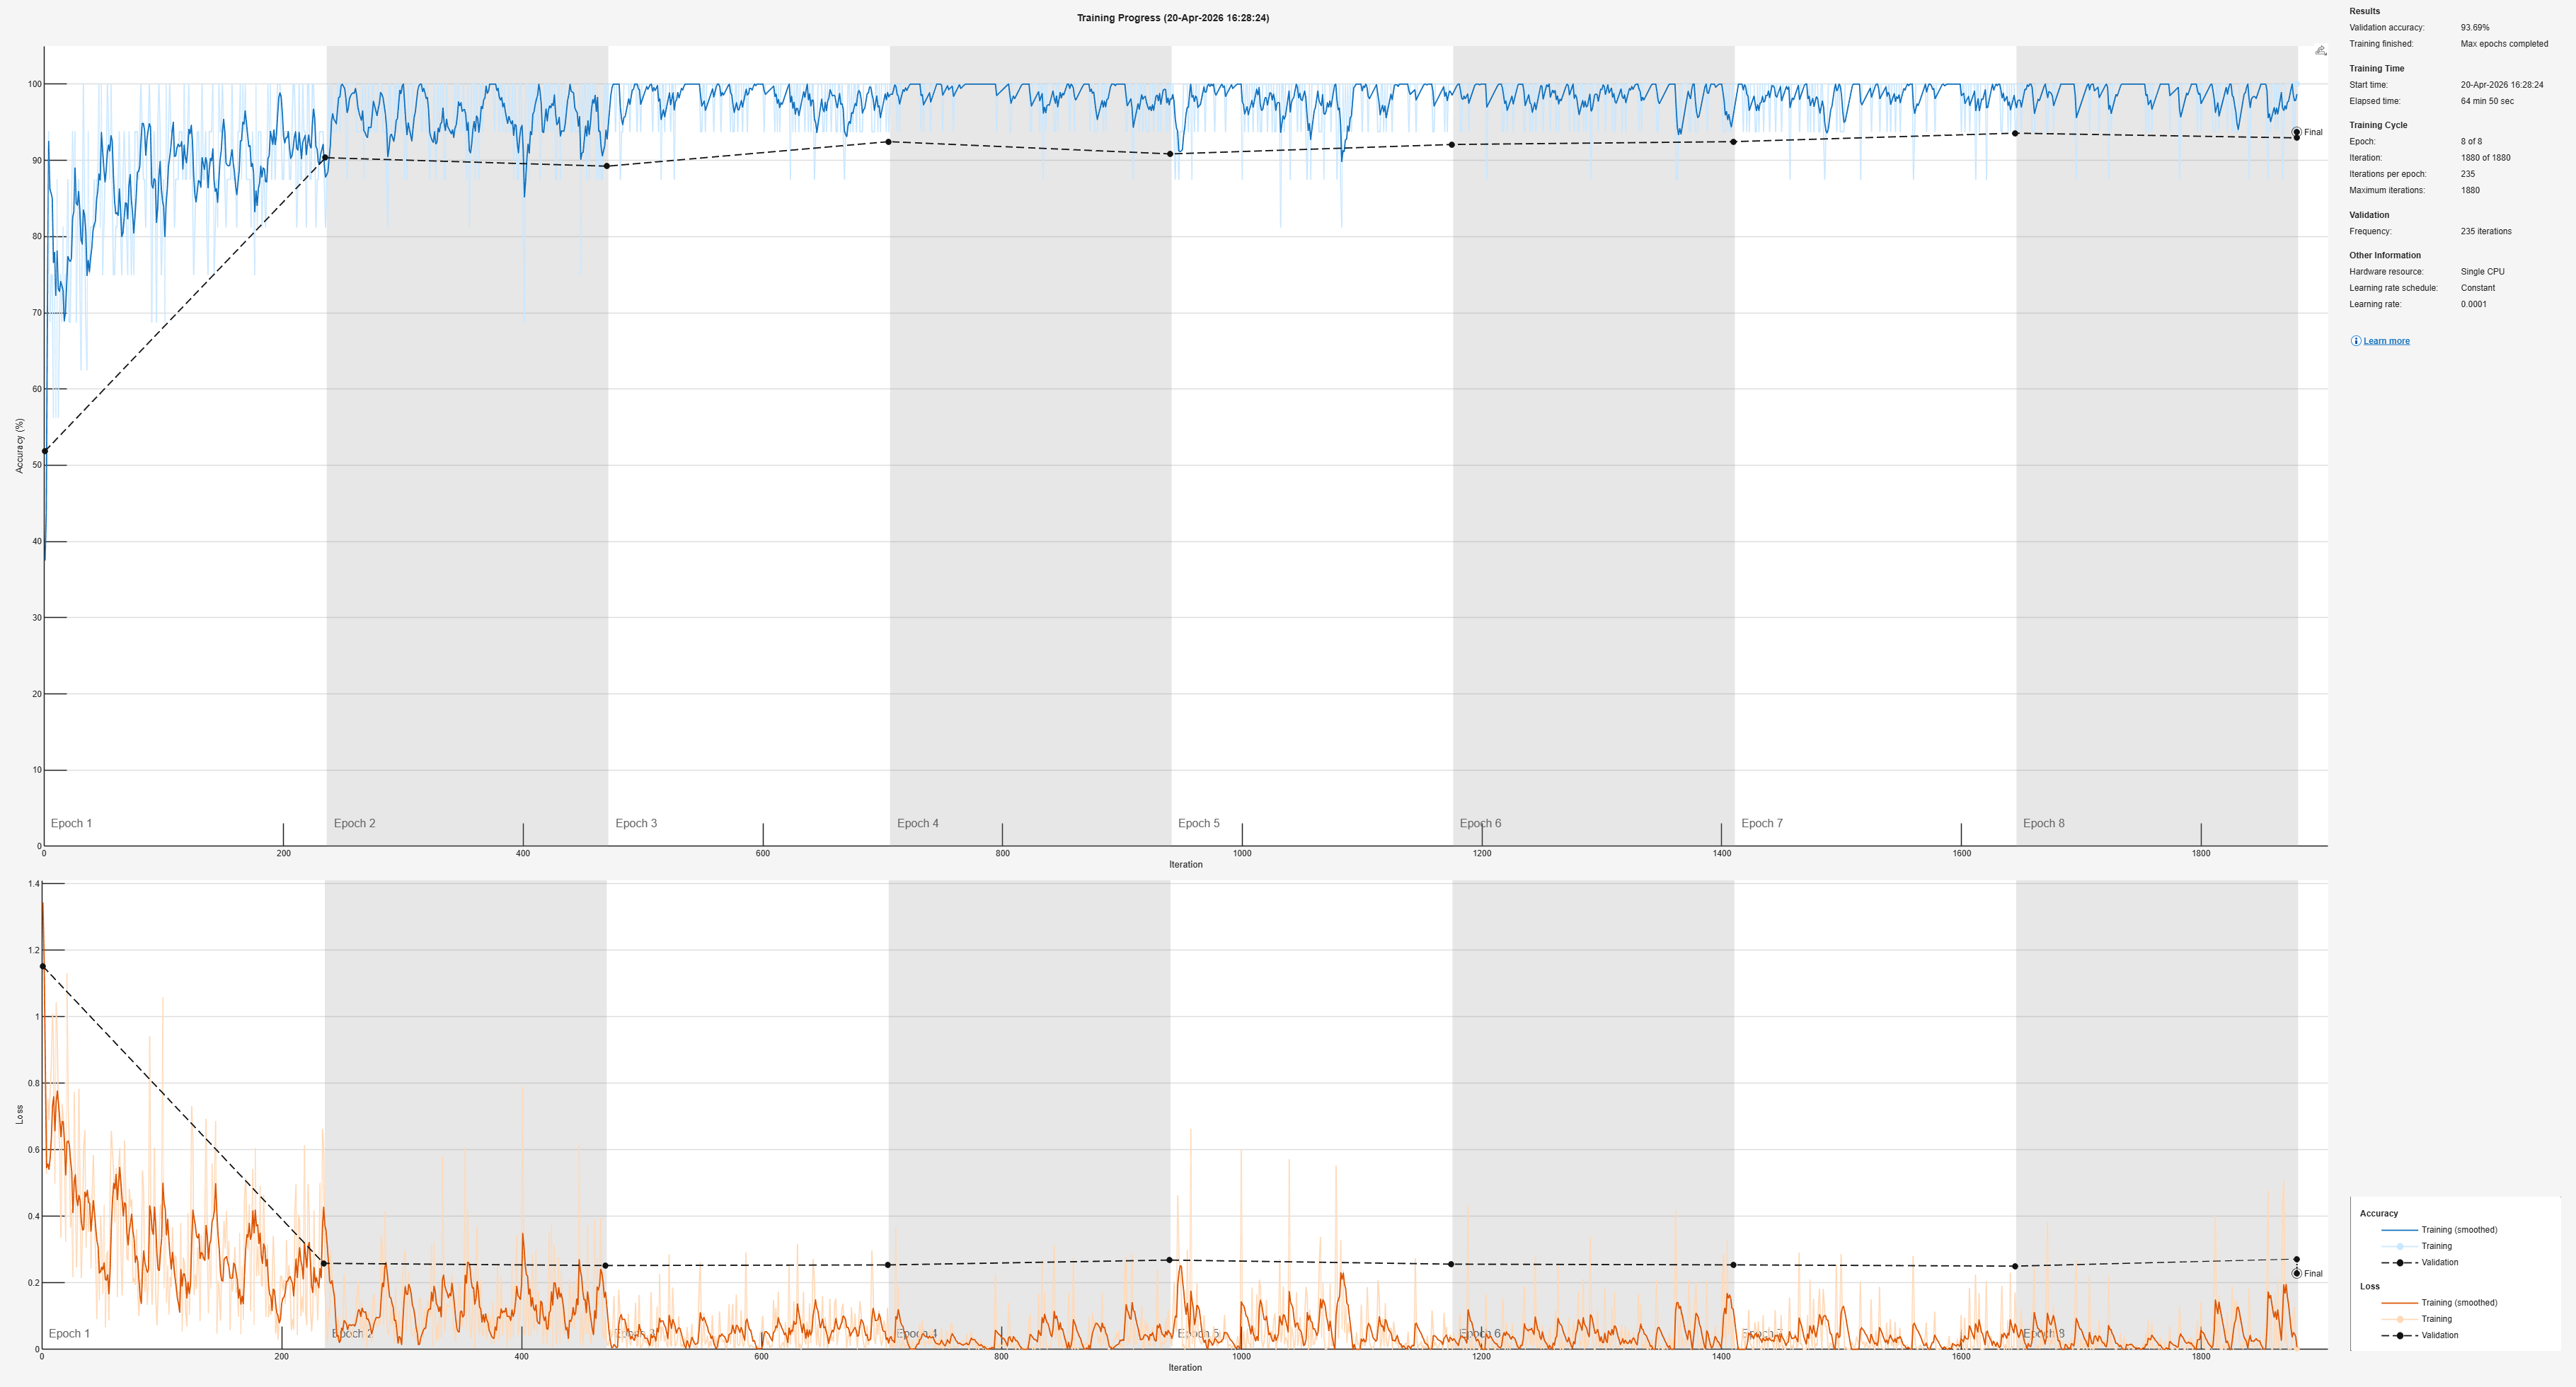

In [31]:
options = trainingOptions('adam', ...                    % changed from sgdm
    'InitialLearnRate', 1e-4, ...
    'MaxEpochs', 8, ...
    'MiniBatchSize', 16, ...
    'Shuffle', 'every-epoch', ...
    'ValidationData', imdsValidation_resized, ...
    'ValidationFrequency', floor(numel(imdsTrain_resized.Files)/16), ...
    'Verbose', false, ...
    'Plots', 'training-progress');


[netResNet, infoResNet] = trainNetwork(imdsTrain_resized, lgraph, options);

In [32]:


% Save immediately after training
save('resnet_results.mat', 'netResNet', 'infoResNet');


## Validation & Test Accuracy

In [33]:
% =========================================================
% 3.5 EVALUATE — VALIDATION & TEST ACCURACY
% =========================================================


% Classify validation set
YPredVal  = classify(netResNet, imdsValidation_resized);
YVal      = imdsValidation.Labels;
valAcc    = sum(YPredVal == YVal) / numel(YVal) * 100;


% Classify test set
YPredTest = classify(netResNet, imdsTest_resized);
YTest     = imdsTest.Labels;
testAcc   = sum(YPredTest == YTest) / numel(YTest) * 100;


fprintf('ResNet-50 Validation Accuracy: %.2f%%\n', valAcc)

ResNet-50 Validation Accuracy: 93.69%

In [34]:
fprintf('ResNet-50 Test Accuracy:       %.2f%%\n', testAcc)

ResNet-50 Test Accuracy:       93.32%

In [35]:
% =========================================================
% ACCURACY CURVE — ResNet-50
% =========================================================


% --- Training accuracy: average per epoch ---
numEpochs    = 8;
miniBatch    = 16;
iterPerEpoch = floor(numel(imdsTrain.Files) / miniBatch);


trainAcc_curve = zeros(1, numEpochs);
for e = 1:numEpochs
    startIdx = (e-1)*iterPerEpoch + 1;
    endIdx   = min(e*iterPerEpoch, numel(infoResNet.TrainingAccuracy));
    trainAcc_curve(e) = mean(infoResNet.TrainingAccuracy(startIdx:endIdx), 'omitnan');
end


% --- Validation accuracy: just extract non-NaN values ---
valAcc_curve = infoResNet.ValidationAccuracy;
valAcc_curve = valAcc_curve(~isnan(valAcc_curve));  % keep only real values


fprintf('Number of validation points captured: %d\n', numel(valAcc_curve))

Number of validation points captured: 9


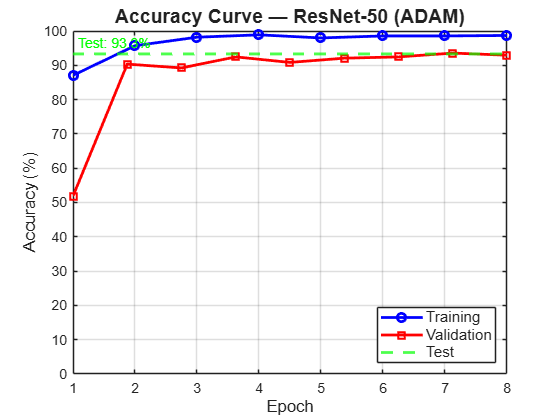

In [36]:


% --- Plot ---
figure('Name', 'Accuracy Curve - ResNet-50', 'NumberTitle', 'off')
epochs = 1:numEpochs;


plot(epochs, trainAcc_curve, 'b-o', 'LineWidth', 2, 'MarkerSize', 6)
hold on


% Plot val curve against its own x points since frequency != per epoch
valX = linspace(1, numEpochs, numel(valAcc_curve));
plot(valX, valAcc_curve, 'r-s', 'LineWidth', 2, 'MarkerSize', 6)


yline(testAcc, 'g--', sprintf('Test: %.1f%%', testAcc), ...
    'LineWidth', 2, 'LabelHorizontalAlignment', 'left')
hold off


xlabel('Epoch', 'FontSize', 12)
ylabel('Accuracy (%)', 'FontSize', 12)
title('Accuracy Curve — ResNet-50 (ADAM)', 'FontSize', 14)
legend({'Training', 'Validation', 'Test'}, 'Location', 'southeast', 'FontSize', 11)
xlim([1 numEpochs])
ylim([0 100])
xticks(epochs)
grid on

In [37]:
save('full_project_workspace.mat')

In [38]:
load('full_project_workspace.mat')


## Confusion Matrix


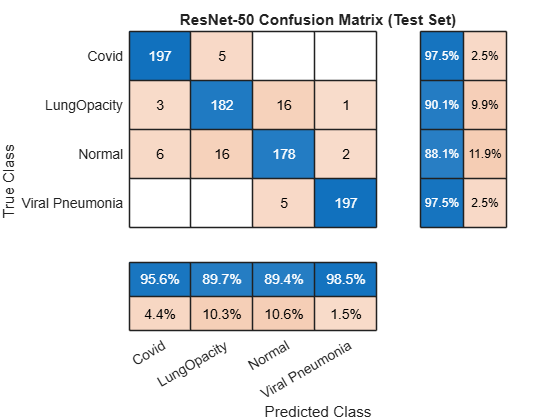

In [39]:
% =========================================================
% 3.6 CONFUSION MATRIX
% =========================================================


figure('Name', 'ResNet-50 Confusion Matrix', 'NumberTitle', 'off')
cm = confusionchart(YTest, YPredTest, ...
    'Title',                  'ResNet-50 Confusion Matrix (Test Set)', ...
    'RowSummary',             'row-normalized', ...
    'ColumnSummary',          'column-normalized');

In [40]:
% =========================================================
% 3.7 PRECISION / RECALL / F1
% =========================================================


classes    = categories(YTest);
numClasses = numel(classes);


precision = zeros(numClasses, 1);
recall    = zeros(numClasses, 1);
f1        = zeros(numClasses, 1);


for c = 1:numClasses
    % True positives, false positives, false negatives
    TP = sum(YPredTest == classes{c} & YTest == classes{c});
    FP = sum(YPredTest == classes{c} & YTest ~= classes{c});
    FN = sum(YPredTest ~= classes{c} & YTest == classes{c});


    precision(c) = TP / (TP + FP + eps);
    recall(c)    = TP / (TP + FN + eps);
    f1(c)        = 2 * (precision(c) * recall(c)) / (precision(c) + recall(c) + eps);
end


% Print results per class
fprintf('\n%-20s  %10s  %10s  %10s\n', 'Class', 'Precision', 'Recall', 'F1 Score')

Class                  Precision      Recall    F1 Score

In [41]:
fprintf('%s\n', repmat('-', 1, 55))

-------------------------------------------------------

In [42]:
for c = 1:numClasses
    fprintf('%-20s  %9.2f%%  %9.2f%%  %9.2f%%\n', ...
        classes{c}, precision(c)*100, recall(c)*100, f1(c)*100)
end

Covid                     95.63%      97.52%      96.57%
LungOpacity               89.66%      90.10%      89.88%
Normal                    89.45%      88.12%      88.78%
Viral Pneumonia           98.50%      97.52%      98.01%

In [43]:


% Macro averages (average across all classes)
fprintf('%s\n', repmat('-', 1, 55))

-------------------------------------------------------

In [44]:
fprintf('%-20s  %9.2f%%  %9.2f%%  %9.2f%%\n', ...
    'Macro Average', mean(precision)*100, mean(recall)*100, mean(f1)*100)

Macro Average             93.31%      93.32%      93.31%


## MODEL 3 EfficientNet\-B0 (2019)

In [45]:
% =========================================================
% SECTION 4 — MODEL 3: EfficientNet-B0
% =========================================================


% 4.1 Load Pretrained EfficientNet-B0
net = efficientnetb0;
lgraphEff = layerGraph(net);


% Check input size
inputSizeEff = net.Layers(1).InputSize;
fprintf('EfficientNet input size: %dx%dx%d\n', ...
    inputSizeEff(1), inputSizeEff(2), inputSizeEff(3))

EfficientNet input size: 224x224x3

In [46]:


% =========================================================
% 4.2 MODIFY FINAL LAYERS (4 classes)
% =========================================================


% Check the last few layers to find the right layer names
net.Layers(end-4:end)

ans = 
  5x1 Layer array with layers:
     1   'efficientnet-b0|model|head|MulLayer'                               Element-wise Multiplication   Element-wise multiplication of 2 inputs
     2   'efficientnet-b0|model|head|global_average_pooling2d|GlobAvgPool'   2-D Global Average Pooling    2-D global average pooling
     3   'efficientnet-b0|model|head|dense|MatMul'                           Fully Connected               1000 fully connected layer
     4   'Softmax'                                                           Softmax                       softmax
     5   'classification'                                                    Classification Output         crossentropyex with 'tench' and 999 other classes

In [47]:
% =========================================================
% 4.2 MODIFY FINAL LAYERS (4 classes)
% =========================================================


numClasses = 4;


newLayers = [
    fullyConnectedLayer(numClasses, 'Name', 'fc_new', ...
        'WeightLearnRateFactor', 20, ...
        'BiasLearnRateFactor', 20)
    softmaxLayer('Name', 'softmax_new')
    classificationLayer('Name', 'classification_new')];


% Replace the last 3 layers
lgraphEff = replaceLayer(lgraphEff, 'efficientnet-b0|model|head|dense|MatMul', newLayers(1));
lgraphEff = replaceLayer(lgraphEff, 'Softmax', newLayers(2));
lgraphEff = replaceLayer(lgraphEff, 'classification', newLayers(3));

In [48]:
% =========================================================
% 4.3 RESIZE IMAGES (224x224x3)
% =========================================================


inputSizeEff = [224 224 3];


imdsTrain_resizedEff = augmentedImageDatastore(inputSizeEff, imdsTrain, ...
    'ColorPreprocessing', 'gray2rgb');


imdsValidation_resizedEff = augmentedImageDatastore(inputSizeEff, imdsValidation, ...
    'ColorPreprocessing', 'gray2rgb');


imdsTest_resizedEff = augmentedImageDatastore(inputSizeEff, imdsTest, ...
    'ColorPreprocessing', 'gray2rgb');

In [49]:
% =========================================================
% 4.4 TRAIN WITH ADAM
% =========================================================


optionsEff = trainingOptions('adam', ...
    'InitialLearnRate', 1e-4, ...
    'MaxEpochs', 8, ...
    'MiniBatchSize', 16, ...
    'Shuffle', 'every-epoch', ...
    'ValidationData', imdsValidation_resizedEff, ...
    'ValidationFrequency', floor(numel(imdsTrain.Files)/16), ...
    'Verbose', false, ...
    'Plots', 'training-progress');


fprintf('Training EfficientNet-B0 with ADAM...\n')

Training EfficientNet-B0 with ADAM...


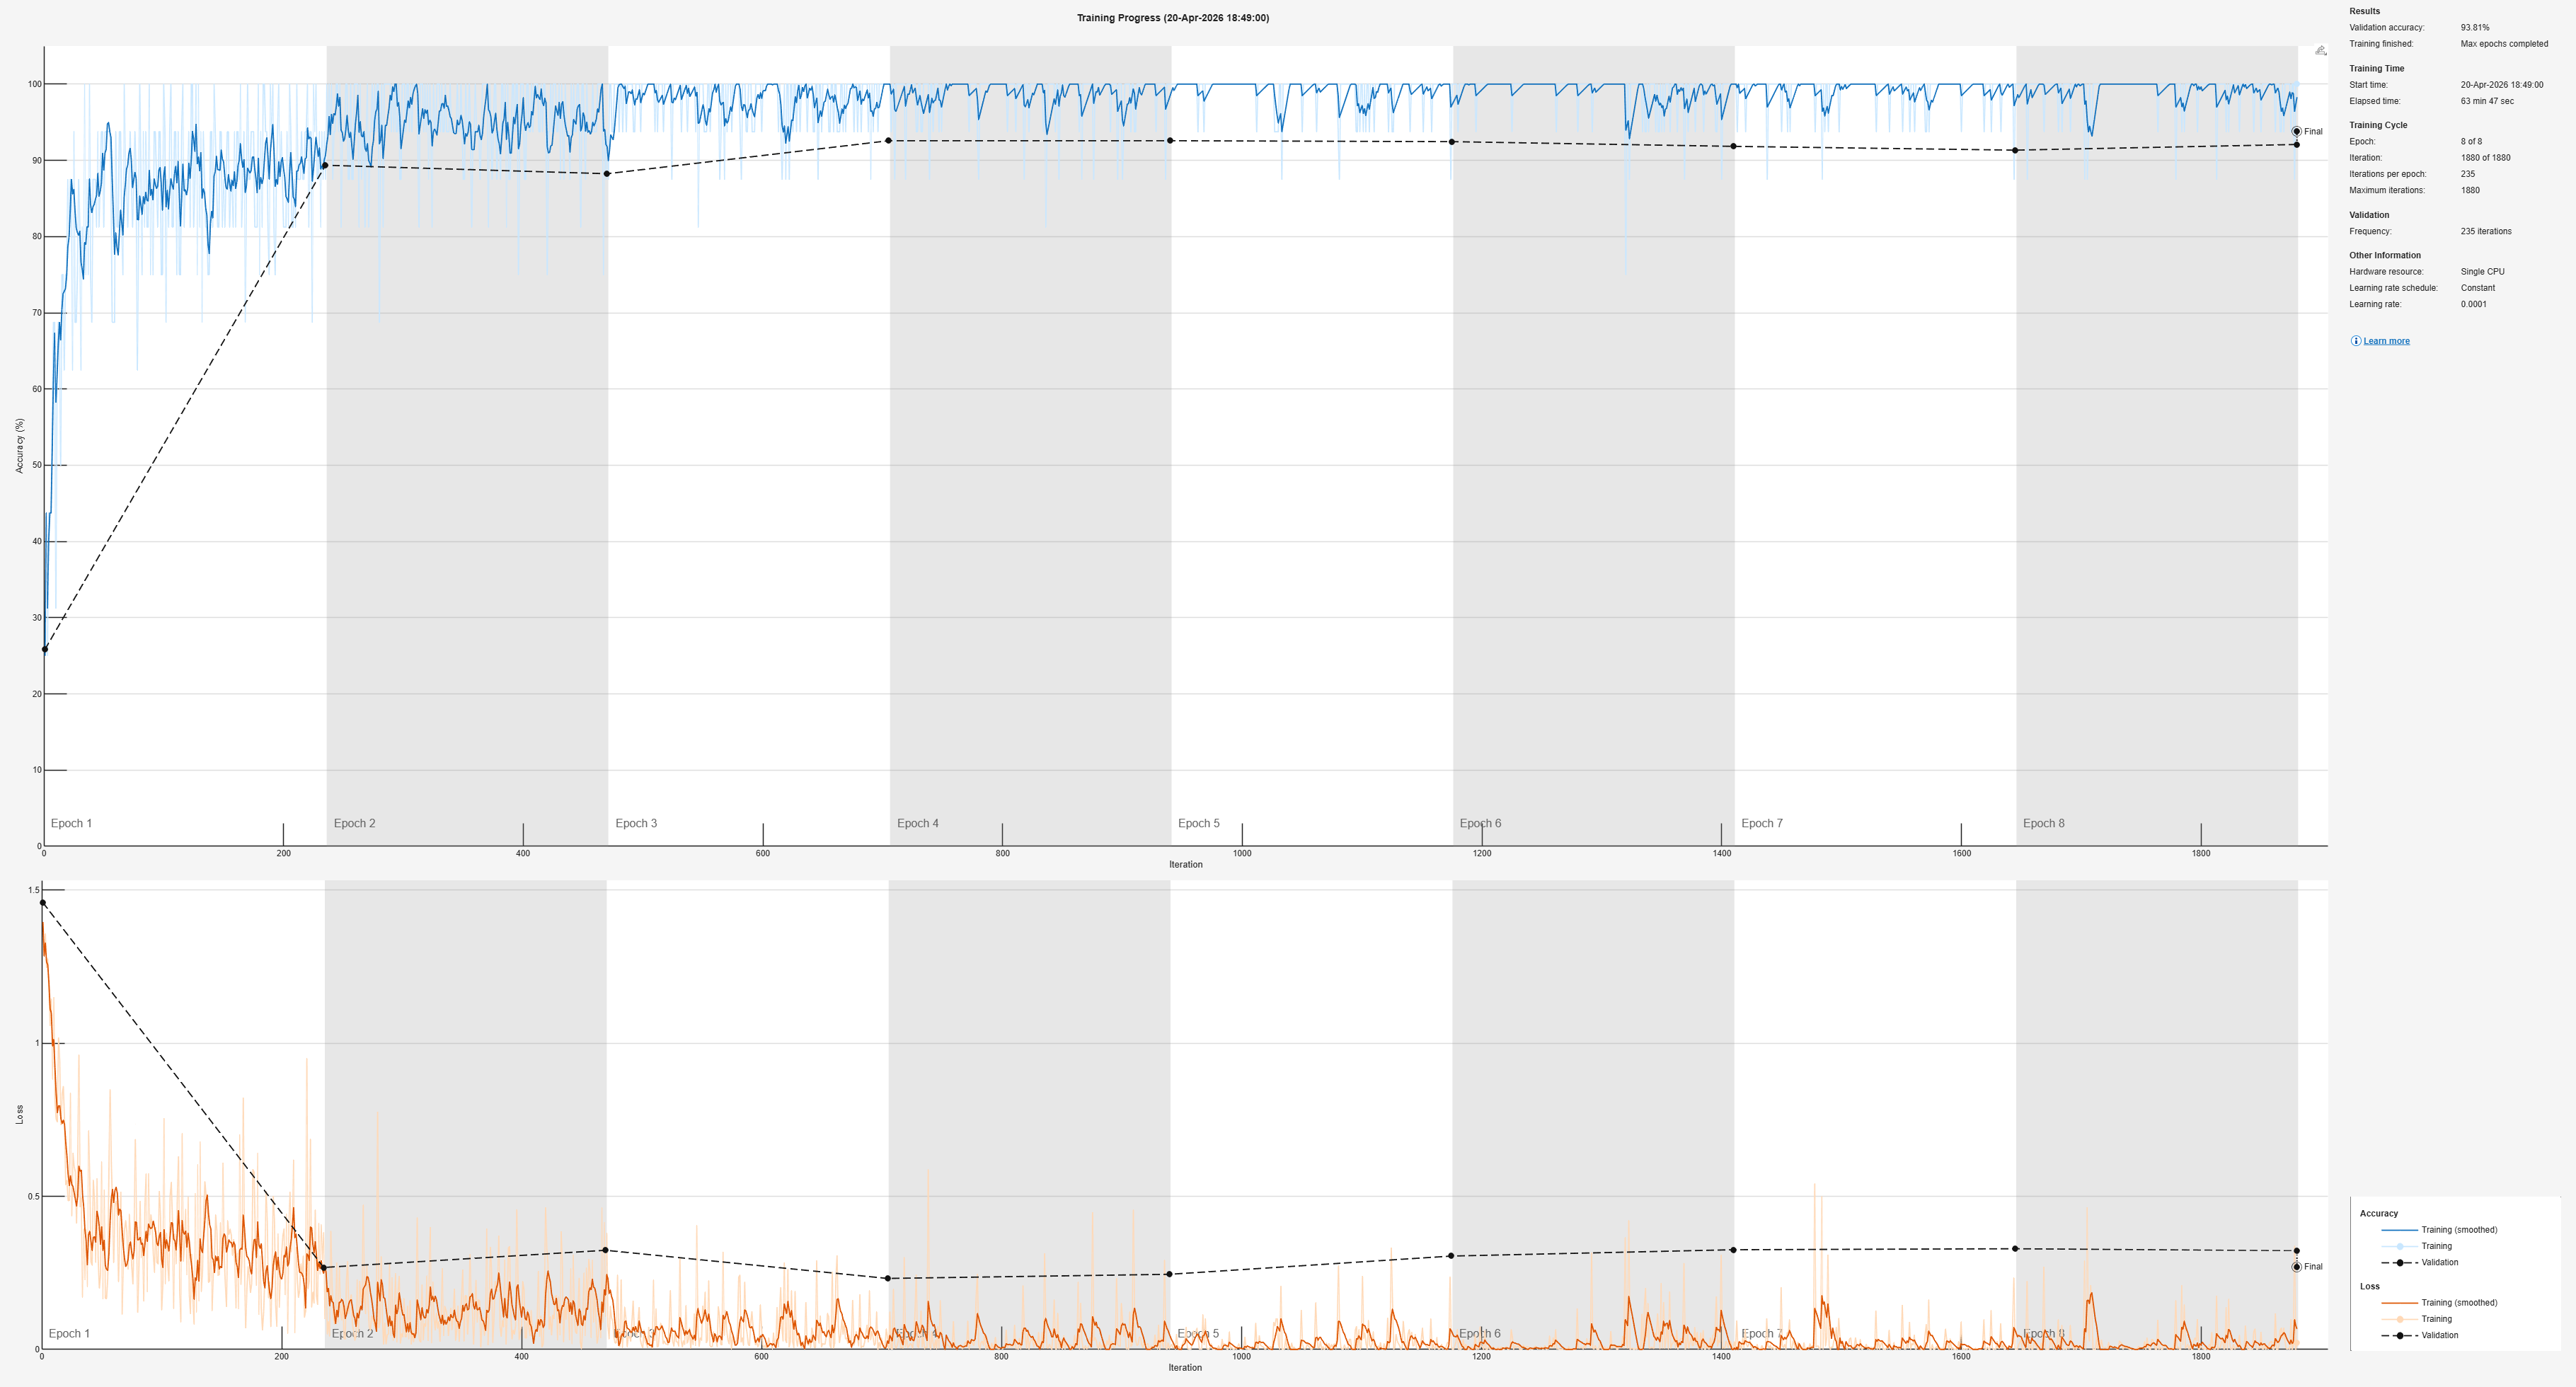

In [50]:
[netEff, infoEff] = trainNetwork(imdsTrain_resizedEff, lgraphEff, optionsEff);

In [51]:


% Save immediately after training
save('full_project_workspace.mat')
fprintf('Workspace saved!\n')

Workspace saved!

In [52]:
% =========================================================
% 4.5 EVALUATE — VAL & TEST ACCURACY
% =========================================================


% Validation Accuracy
YPredVal = classify(netEff, imdsValidation_resizedEff);
YVal     = imdsValidation.Labels;
valAccEff = sum(YPredVal == YVal) / numel(YVal) * 100;
fprintf('EfficientNet Validation Accuracy: %.2f%%\n', valAccEff)

EfficientNet Validation Accuracy: 93.81%

In [53]:


% Test Accuracy
YPredTest = classify(netEff, imdsTest_resizedEff);
YTest     = imdsTest.Labels;
testAccEff = sum(YPredTest == YTest) / numel(YTest) * 100;
fprintf('EfficientNet Test Accuracy: %.2f%%\n', testAccEff)

EfficientNet Test Accuracy: 93.69%


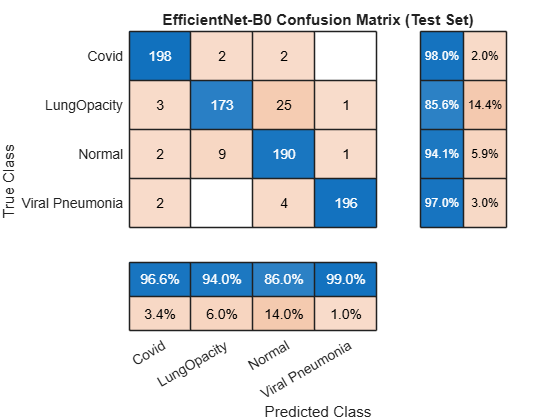

In [54]:
% =========================================================
% 4.6 CONFUSION MATRIX
% =========================================================


figure('Name', 'EfficientNet-B0 Confusion Matrix', 'NumberTitle', 'off')
confusionchart(YTest, YPredTest, ...
    'Title',           'EfficientNet-B0 Confusion Matrix (Test Set)', ...
    'RowSummary',      'row-normalized', ...
    'ColumnSummary',   'column-normalized');

In [55]:
% =========================================================
% 4.7 PRECISION / RECALL / F1
% =========================================================


classes    = categories(YTest);
numClasses = numel(classes);


precision = zeros(numClasses, 1);
recall    = zeros(numClasses, 1);
f1        = zeros(numClasses, 1);


for c = 1:numClasses
    TP = sum(YPredTest == classes{c} & YTest == classes{c});
    FP = sum(YPredTest == classes{c} & YTest ~= classes{c});
    FN = sum(YPredTest ~= classes{c} & YTest == classes{c});


    precision(c) = TP / (TP + FP + eps);
    recall(c)    = TP / (TP + FN + eps);
    f1(c)        = 2 * (precision(c) * recall(c)) / (precision(c) + recall(c) + eps);
end


fprintf('\n%-20s  %10s  %10s  %10s\n', 'Class', 'Precision', 'Recall', 'F1 Score')

Class                  Precision      Recall    F1 Score

In [56]:
fprintf('%s\n', repmat('-', 1, 55))

-------------------------------------------------------

In [57]:
for c = 1:numClasses
    fprintf('%-20s  %9.2f%%  %9.2f%%  %9.2f%%\n', ...
        classes{c}, precision(c)*100, recall(c)*100, f1(c)*100)
end

Covid                     96.59%      98.02%      97.30%
LungOpacity               94.02%      85.64%      89.64%
Normal                    85.97%      94.06%      89.83%
Viral Pneumonia           98.99%      97.03%      98.00%

In [58]:
fprintf('%s\n', repmat('-', 1, 55))

-------------------------------------------------------

In [59]:
fprintf('%-20s  %9.2f%%  %9.2f%%  %9.2f%%\n', ...
    'Macro Average', mean(precision)*100, mean(recall)*100, mean(f1)*100)

Macro Average             93.89%      93.69%      93.69%


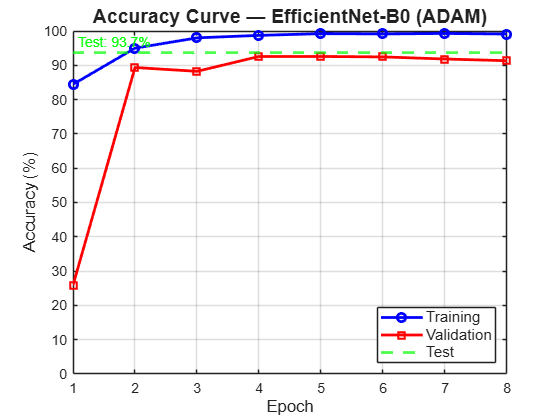

In [60]:
% =========================================================
% 4.8 ACCURACY CURVE — EfficientNet-B0
% =========================================================


numEpochs    = 8;
miniBatch    = 16;
iterPerEpoch = floor(numel(imdsTrain.Files) / miniBatch);


% --- Training accuracy: average per epoch ---
trainAcc_curveEff = zeros(1, numEpochs);
for e = 1:numEpochs
    startIdx = (e-1)*iterPerEpoch + 1;
    endIdx   = min(e*iterPerEpoch, numel(infoEff.TrainingAccuracy));
    trainAcc_curveEff(e) = mean(infoEff.TrainingAccuracy(startIdx:endIdx), 'omitnan');
end


% --- Validation accuracy: extract non-NaN values ---
valAcc_curveEff = infoEff.ValidationAccuracy;
valAcc_curveEff = valAcc_curveEff(~isnan(valAcc_curveEff));
valAcc_curveEff = valAcc_curveEff(1:min(numEpochs, numel(valAcc_curveEff)));


% --- Plot ---
epochs = 1:numEpochs;
figure('Name', 'Accuracy Curve - EfficientNet-B0', 'NumberTitle', 'off')
plot(epochs, trainAcc_curveEff, 'b-o', 'LineWidth', 2, 'MarkerSize', 6)
hold on
plot(epochs, valAcc_curveEff, 'r-s', 'LineWidth', 2, 'MarkerSize', 6)
yline(testAccEff, 'g--', sprintf('Test: %.1f%%', testAccEff), ...
    'LineWidth', 2, 'LabelHorizontalAlignment', 'left')
hold off
xlabel('Epoch', 'FontSize', 12)
ylabel('Accuracy (%)', 'FontSize', 12)
title('Accuracy Curve — EfficientNet-B0 (ADAM)', 'FontSize', 14)
legend({'Training', 'Validation', 'Test'}, 'Location', 'southeast', 'FontSize', 11)
xlim([1 numEpochs])
ylim([0 100])
xticks(epochs)
grid on

In [61]:
save('full_project_workspace.mat')

In [62]:
load('full_project_workspace.mat')

In [63]:
% =========================================================
% SECTION 6 — COMPARISON
% =========================================================


% =========================================================
% 6.1 SUMMARY TABLE
% =========================================================


% --- Collect all results ---
cnn_sgdm_val  = results{1,2};  cnn_sgdm_test  = results{1,3};
cnn_adam_val  = results{2,2};  cnn_adam_test  = results{2,3};
cnn_rms_val   = results{3,2};  cnn_rms_test   = results{3,3};


resnet_val  = valAcc;     resnet_test  = testAcc;
eff_val     = valAccEff;  eff_test     = testAccEff;


% --- Build Summary Table ---
ModelName = {'Custom CNN (SGDM)'; 'Custom CNN (ADAM)'; 'Custom CNN (RMSProp)'; ...
             'ResNet-50 (ADAM)'; 'EfficientNet-B0 (ADAM)'};


ValidationAccuracy = [cnn_sgdm_val; cnn_adam_val; cnn_rms_val; resnet_val; eff_val];
TestAccuracy       = [cnn_sgdm_test; cnn_adam_test; cnn_rms_test; resnet_test; eff_test];


summaryTable = table(ModelName, ValidationAccuracy, TestAccuracy);


disp('========== FULL MODEL COMPARISON SUMMARY ==========')

========== FULL MODEL COMPARISON SUMMARY ==========

In [64]:
disp(summaryTable)

            ModelName             ValidationAccuracy    TestAccuracy
    __________________________    __________________    ____________
    {'Custom CNN (SGDM)'     }          82.673             82.426   
    {'Custom CNN (ADAM)'     }          84.653             86.015   
    {'Custom CNN (RMSProp)'  }          84.653             84.158   
    {'ResNet-50 (ADAM)'      }          93.688             93.317   
    {'EfficientNet-B0 (ADAM)'}          93.812             93.688


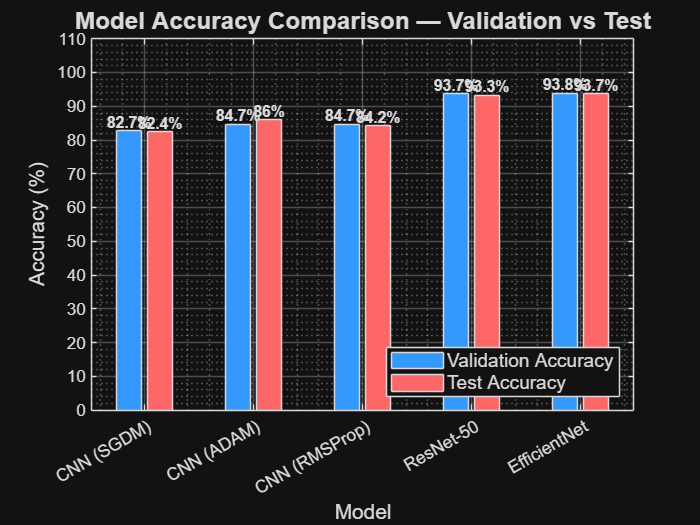

In [65]:
% =========================================================
% 6.2 BAR CHART — ACCURACY COMPARISON
% =========================================================


modelNames = {'CNN (SGDM)', 'CNN (ADAM)', 'CNN (RMSProp)', ...
              'ResNet-50', 'EfficientNet'};


valAccAll  = [cnn_sgdm_val;  cnn_adam_val;  cnn_rms_val;  resnet_val;  eff_val];
testAccAll = [cnn_sgdm_test; cnn_adam_test; cnn_rms_test; resnet_test; eff_test];


figure('Name', 'Model Accuracy Comparison', 'NumberTitle', 'off')
barData = [valAccAll, testAccAll];
b = bar(barData, 'grouped');


b(1).FaceColor = [0.2 0.6 1.0];   % blue  - validation
b(2).FaceColor = [1.0 0.4 0.4];   % red   - test


% Add value labels on top of each bar
for i = 1:2
    xData = b(i).XEndPoints;
    yData = b(i).YEndPoints;
    labels = string(round(barData(:,i), 1)) + '%';
    text(xData, yData, labels, ...
        'HorizontalAlignment', 'center', ...
        'VerticalAlignment',   'bottom', ...
        'FontSize', 9, ...
        'FontWeight', 'bold')
end


xlabel('Model', 'FontSize', 12)
ylabel('Accuracy (%)', 'FontSize', 12)
title('Model Accuracy Comparison — Validation vs Test', 'FontSize', 14)
legend({'Validation Accuracy', 'Test Accuracy'}, ...
    'Location', 'southeast', 'FontSize', 11)
xticklabels(modelNames)
ylim([0 110])
grid on
grid minor

In [66]:
% =========================================================
% 6.3 BEST MODEL IDENTIFIED
% =========================================================


allTestAcc = [cnn_sgdm_test, cnn_adam_test, cnn_rms_test, resnet_test, eff_test];
allValAcc  = [cnn_sgdm_val,  cnn_adam_val,  cnn_rms_val,  resnet_val,  eff_val];
allNames   = {'Custom CNN (SGDM)', 'Custom CNN (ADAM)', 'Custom CNN (RMSProp)', ...
              'ResNet-50 (ADAM)', 'EfficientNet-B0 (ADAM)'};


[bestTestAcc, bestIdx] = max(allTestAcc);


% --- Best Model Table ---
BestModel        = allNames(bestIdx);
BestValAccuracy  = allValAcc(bestIdx);
BestTestAccuracy = bestTestAcc;


bestTable = table(BestModel', BestValAccuracy', BestTestAccuracy', ...
    'VariableNames', {'Model', 'ValidationAccuracy', 'TestAccuracy'});


disp('========== BEST MODEL ==========')

========== BEST MODEL ==========

In [67]:
disp(bestTable)

              Model               ValidationAccuracy    TestAccuracy
    __________________________    __________________    ____________
    {'EfficientNet-B0 (ADAM)'}          93.812             93.688

In [68]:


% --- Overfitting Check Table ---
ModelName2  = allNames';
Gap         = (allValAcc - allTestAcc)';
Status      = cell(numel(allNames), 1);


for i = 1:numel(allNames)
    if abs(Gap(i)) <= 2
        Status{i} = 'Good Generalisation';
    elseif Gap(i) > 2
        Status{i} = 'Slight Overfitting';
    else
        Status{i} = 'Underfitting';
    end
end


overfitTable = table(ModelName2, Gap, Status, ...
    'VariableNames', {'Model', 'ValTestGap', 'Status'});


disp('========== OVERFITTING CHECK ==========')

========== OVERFITTING CHECK ==========

In [69]:
disp(overfitTable)

              Model               ValTestGap            Status         
    __________________________    __________    _______________________
    {'Custom CNN (SGDM)'     }     0.24752      {'Good Generalisation'}
    {'Custom CNN (ADAM)'     }     -1.3614      {'Good Generalisation'}
    {'Custom CNN (RMSProp)'  }     0.49505      {'Good Generalisation'}
    {'ResNet-50 (ADAM)'      }     0.37129      {'Good Generalisation'}
    {'EfficientNet-B0 (ADAM)'}     0.12376      {'Good Generalisation'}

In [70]:


% --- Transfer Learning vs Custom CNN ---
bestCNNTest = max([cnn_sgdm_test, cnn_adam_test, cnn_rms_test]);
bestPTTest  = max([resnet_test, eff_test]);


fprintf('\n')
if bestPTTest > bestCNNTest
    fprintf('Transfer Learning improved accuracy by %.2f%% over best Custom CNN\n', ...
        bestPTTest - bestCNNTest)
else
    fprintf('Custom CNN outperformed Transfer Learning by %.2f%%\n', ...
        bestCNNTest - bestPTTest)
end

Transfer Learning improved accuracy by 7.67% over best Custom CNN

In [71]:
save('full_project_workspace.mat')